# Projeto Sprint 9 — Tomando Decisões de Negócios Baseadas em Dados


### Contexto

Uma loja online quer aumentar sua receita e está avaliando **9 hipóteses** levantadas pelo time de marketing.
Antes de executar um teste A/B, precisamos **priorizar** quais hipóteses têm mais chances de gerar resultado com o menor esforço possível.


### Dados disponíveis

| Arquivo | Conteúdo |
|---------|----------|
| `hypotheses_us.csv` | 9 hipóteses com pontuações de Reach, Impact, Confidence e Effort |
| `orders_us.csv` | Pedidos realizados durante o teste A/B (grupos A e B) |
| `visits_us.csv` | Visitas diárias por grupo (A e B) durante o teste |

In [1]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Carregando os dados
hipoteses = pd.read_csv('hypotheses_us.csv', sep=';')
pedidos   = pd.read_csv('orders_us.csv')
visitas   = pd.read_csv('visits_us.csv')

print('--------------- Hipóteses ---------------')

hipoteses


--------------- Hipóteses ---------------


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


# Priorização de Hipóteses com ICE e RICE Score

### ICE Score

O **ICE** é um framework simples de priorização com três critérios:

- **Impact (Impacto):** o quanto essa hipótese pode impactar o negócio se funcionar (escala 1–10)
- **Confidence (Confiança):** o quão confiante a equipe está de que a hipótese funcionará (escala 1–10)
- **Effort (Esforço):** o quanto de trabalho será necessário para implementar (escala 1–10, onde **10 = muito esforço**)

**Fórmula:**

$$ICE = \frac{Impact \times Confidence}{Effort}$$

> Hipóteses com **ICE alto** combinam grande impacto, alta confiança e baixo esforço — são as que devemos testar primeiro.

A função `calcular_ice()` percorre cada linha do DataFrame usando `iterrows()`, calcula o score e monta uma tabela ordenada.

In [ ]:
def calcular_ice(df):
    resultados = []

    # Percorre cada linha (hipótese) do DataFrame
    for index, row in df.iterrows():
        # Fórmula ICE: (Impact × Confidence) / Effort
        ice = (row['Impact'] * row['Confidence']) / row['Effort']

        resultados.append({
            'Hipotese':   index + 1,
            'Descricao':  row['Hypothesis'][:70] + '...',
            'Impact':     row['Impact'],
            'Confidence': row['Confidence'],
            'Effort':     row['Effort'],
            'ICE_Score':  round(ice, 2)
        })

    # Transforma a lista em DataFrame e ordena do maior ICE para o menor
    resultado_df = pd.DataFrame(resultados)
    resultado_df = resultado_df.sort_values('ICE_Score', ascending=False)
    resultado_df = resultado_df.reset_index(drop=True)
    resultado_df.index = resultado_df.index + 1  # Ranking começa em 1, não em 0
    return resultado_df


df_ice = calcular_ice(hipoteses)
print('Ranking por ICE Score (1 = maior prioridade):')
df_ice


Ranking por ICE Score (1 = maior prioridade):


,Hipotese,Descricao,Impact,Confidence,Effort,ICE_Score
1,9,Launch a promotion that gives users discounts ...,9,9,5,16.20
2,1,Add two new channels for attracting traffic. T...,10,8,6,13.33
3,8,Add a subscription form to all the main pages....,7,8,5,11.20
4,7,Show banners with current offers and sales on ...,3,8,3,8.00
5,3,Add product recommendation blocks to the store...,3,7,3,7.00
6,2,Launch your own delivery service. This will sh...,5,4,10,2.00
7,6,Add a customer review page. This will increase...,2,2,3,1.33
8,4,Change the category structure. This will incre...,3,3,8,1.12
9,5,Change the background color on the main page. ...,1,1,1,1.00


## Parte 2 — RICE Score

O **RICE** é uma evolução do ICE que adiciona um quarto critério:

- **Reach (Alcance):** estimativa de quantas pessoas serão afetadas por essa mudança (número de usuários/pontos)
- **Impact (Impacto):** o quanto impacta cada usuário afetado (escala 1–10)
- **Confidence (Confiança):** o quão confiante a equipe está (escala 1–10)
- **Effort (Esforço):** o trabalho necessário para implementar (escala 1–10)

**Fórmula:**

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

> A grande diferença do RICE em relação ao ICE é considerar **quantas pessoas** serão impactadas.
> Uma hipótese que beneficia muitos usuários sobe no ranking, mesmo que o impacto individual seja menor.

Seguimos o mesmo padrão da função ICE: `iterrows()` linha por linha.

In [12]:
def calcular_rice(df):
    resultados = []

    # Percorre cada linha (hipótese) do DataFrame
    for index, row in df.iterrows():
        # Fórmula RICE: (Reach × Impact × Confidence) / Effort
        rice = (row['Reach'] * row['Impact'] * row['Confidence']) / row['Effort']

        resultados.append({
            'Hipotese':   index + 1,
            'Descricao':  row['Hypothesis'][:70] + '...',
            'Reach':      row['Reach'],
            'Impact':     row['Impact'],
            'Confidence': row['Confidence'],
            'Effort':     row['Effort'],
            'RICE_Score': round(rice, 2)
        })

    # Transforma a lista em DataFrame e ordena do maior RICE para o menor
    resultado_df = pd.DataFrame(resultados)
    resultado_df = resultado_df.sort_values('RICE_Score', ascending=False)
    resultado_df = resultado_df.reset_index(drop=True)
    resultado_df.index = resultado_df.index + 1  # Ranking começa em 1, não em 0
    return resultado_df


df_rice = calcular_rice(hipoteses)
print('Ranking por RICE Score (1 = maior prioridade):')
df_rice


Ranking por RICE Score (1 = maior prioridade):


,Hipotese,Descricao,Reach,Impact,Confidence,Effort,RICE_Score
1,8,Add a subscription form to all the main pages....,10,7,8,5,112.0
2,3,Add product recommendation blocks to the store...,8,3,7,3,56.0
3,1,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
4,7,Show banners with current offers and sales on ...,5,3,8,3,40.0
5,9,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
6,4,Change the category structure. This will incre...,8,3,3,8,9.0
7,2,Launch your own delivery service. This will sh...,2,5,4,10,4.0
8,6,Add a customer review page. This will increase...,3,2,2,3,4.0
9,5,Change the background color on the main page. ...,3,1,1,1,3.0


## Parte 3 — Comparação ICE vs RICE

Agora vamos comparar os dois rankings lado a lado.

A coluna **`Diferenca_de_Rank`** mostra o quanto cada hipótese se moveu entre os dois frameworks.
Isso revela o impacto da variável **Reach** na priorização:

- **Hipótese sobe no RICE:** afeta muitas pessoas → mais prioritária quando o alcance é considerado
- **Hipótese cai no RICE:** afeta poucas pessoas → menos prioritária quando o alcance é considerado
- **Diferença zero:** o Reach não muda a prioridade relativa dessa hipótese

Comparação ICE vs RICE (ordenado pelo ranking ICE):


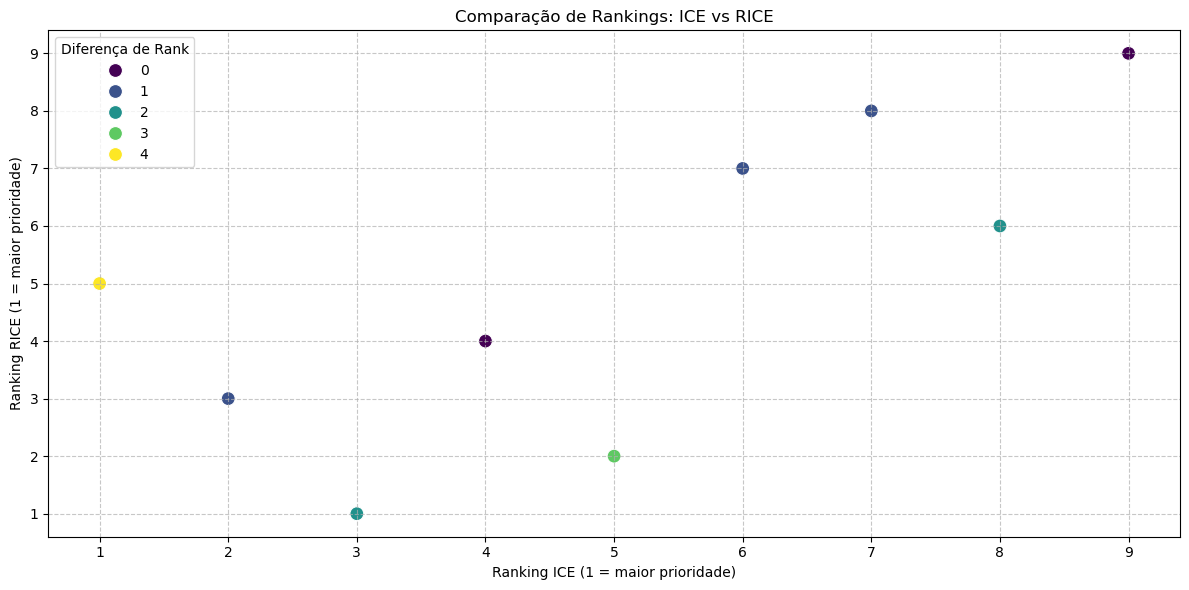

In [17]:
# Extraímos apenas o número da hipótese e seu score de cada ranking
ranking_ice  = df_ice[['Hipotese', 'ICE_Score']].copy()
ranking_rice = df_rice[['Hipotese', 'RICE_Score']].copy()

# Adicionamos a posição no ranking (1 = maior prioridade)
ranking_ice['Rank_ICE']   = range(1, len(ranking_ice) + 1)
ranking_rice['Rank_RICE'] = range(1, len(ranking_rice) + 1)

# Juntamos os dois DataFrames pela coluna Hipotese
comparacao = pd.merge(ranking_ice, ranking_rice, on='Hipotese')

# Calculamos quantas posições cada hipótese subiu ou desceu entre os rankings
comparacao['Diferenca_de_Rank'] = abs(comparacao['Rank_ICE'] - comparacao['Rank_RICE'])

# Ordenamos pelo ranking ICE para facilitar a comparação
comparacao = comparacao.sort_values('Rank_ICE').reset_index(drop=True)
comparacao.index = comparacao.index + 1

# Reordenamos as colunas para leitura mais intuitiva
comparacao = comparacao[['Hipotese', 'Rank_ICE', 'ICE_Score', 'Rank_RICE', 'RICE_Score', 'Diferenca_de_Rank']]

print('Comparação ICE vs RICE (ordenado pelo ranking ICE):')
comparacao

#Grafico de comparação dos rankings
plt.figure(figsize=(12, 6))
sns.scatterplot(data=comparacao, x='Rank_ICE', y='Rank_RICE', hue='Diferenca_de_Rank', palette='viridis', s=100)
plt.title('Comparação de Rankings: ICE vs RICE')
plt.xlabel('Ranking ICE (1 = maior prioridade)')
plt.ylabel('Ranking RICE (1 = maior prioridade)')
plt.legend(title='Diferença de Rank', loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title='Diferença de Rank', loc='upper left')
plt.show()


## Conclusão

### O que os rankings nos dizem?

- Hipóteses com **Reach alto** (como a de formulário de assinatura, Reach=10) tendem a subir no ranking RICE
  porque alcançam muitos usuários ao mesmo tempo.
- Hipóteses com **Reach baixo** (como a promoção de aniversário, Reach=1) caem bastante no RICE,
  pois atingem apenas um subconjunto pequeno de usuários.

### Qual framework usar?

| Situação | Framework recomendado |
|----------|-----------------------|
| Alcance difícil de estimar | **ICE** |
| Todas as hipóteses afetam o mesmo público | **ICE** |
| Alcance varia muito entre as hipóteses | **RICE** |
| Queremos priorizar impacto em escala | **RICE** |

**Para este projeto**, o **RICE é o mais adequado**, pois as hipóteses têm alcances muito diferentes
(de Reach=1 a Reach=10). Usar somente o ICE poderia priorizar hipóteses de alto impacto individual
que, na prática, afetam pouquíssimas pessoas.
